Creates Figure 11 of the main paper

In [1]:
#load packages needed in this notebook
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
from eofs.standard import Eof
import regionmask
import cartopy.crs as ccrs
from matplotlib import pyplot as PP
import copy
import matplotlib as mpl
import matplotlib.patches as mpatches
from cartopy.util import add_cyclic_point

ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/home/nmaher/.conda/envs/clara/share/proj failed


In [2]:
#define models and their start years
models=['CESM2','CESM1-LE','ACCESS-SSP370','CanESM5-SSP370','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']

models_title=['CESM2','CESM1','ACCESS','CanESM5','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']


#tell me when the start year is 
syear=[1850,1920,1850,1850,1921,1850,1850,1850]
#offset=1920-syear

#load lon lat should be same for all models
outputdira='/glade/campaign/cgd/cas/nmaher/cesm1_lens/Amon/zg/' 
ds_fx = xr.open_dataset(outputdira+'zg_Amon_CESM1-CAM5_historical_rcp85_r10i1p1_192001-210012_g025.nc')

lon = ds_fx.lon
lat = ds_fx.lat


In [3]:
#load data
outputdir_figD='/glade/work/nmaher/SEOF_output/Fig_data/'



In [4]:
cdataE_tot=np.zeros([8,4,72,144])
cdataL_tot=np.zeros([8,4,72,144])
cdataE_totT=np.zeros([8,4,72,144])
cdataL_totT=np.zeros([8,4,72,144])

In [5]:
# define 2d lat and lon points for ploting sig locs
lons=lon
lats=lat
lon2d,lat2d = np.meshgrid(lons,lats)

ii=-1
for model in models:
    ii=ii+1
    offset=1921-syear[ii]

    eof_T='_FS1bdata_zgNPac'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_npac = np.ma.MaskedArray(**npz)

    
    eof_T='_FS1bdata_zgNAt'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_nat = np.ma.MaskedArray(**npz)

    

    cnt=0
    ii2=-1
    for i in range(3): 

        ii2=ii2+1
        # grab early data
        cdataE = data_z500_npac[i,0+offset:10+offset,...].mean(axis=0)
        # grab late data
        cdataL = data_z500_npac[i,164+offset:174+offset,...].mean(axis=0)

        cdataE_tot[ii,ii2,:,:]=cdataE
        cdataL_tot[ii,ii2,:,:]=cdataL
    
    for i in range(1): 
        ii2=ii2+1
        # grab early data
        cdataE = data_z500_nat[i,0+offset:10+offset,...].mean(axis=0)
        # grab late data
        cdataL = data_z500_nat[i,164+offset:174+offset,...].mean(axis=0)
 
        cdataE_tot[ii,ii2,:,:]=cdataE
        cdataL_tot[ii,ii2,:,:]=cdataL


    eof_T='_F6data_zg'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500= np.ma.MaskedArray(**npz)

    cnt=0
    ii2=-1
    for i in range(4): 

        ii2=ii2+1
        # grab early data
        cdataET = data_z500[i,0+offset:10+offset,...].mean(axis=0)
        # grab late data
        cdataLT = data_z500[i,164+offset:174+offset,...].mean(axis=0)

        cdataE_totT[ii,ii2,:,:]=cdataET
        cdataL_totT[ii,ii2,:,:]=cdataLT


cdataE=np.mean(cdataE_tot[:,:,:,:],axis=0)
cdataL=np.mean(cdataL_tot[:,:,:,:],axis=0)
cdataET=np.mean(cdataE_totT[:,:,:,:],axis=0)
cdataLT=np.mean(cdataL_totT[:,:,:,:],axis=0)

In [6]:
test=cdataL
testq=cdataE

testT=cdataLT
testTq=cdataET

testM=cdataL_tot
testMq=cdataE_tot

testMT=cdataL_totT
testMTq=cdataE_totT

In [7]:
lat2d, lon2d = np.meshgrid(lats, lons, indexing='ij')

lat_min, lat_max = 20, 90
lon_min, lon_max = 110, 260

# True where we want to KEEP values
keep = (lat2d >= lat_min) & (lat2d <= lat_max) & \
       (lon2d >= lon_min) & (lon2d <= lon_max)


In [8]:
rmsa = np.zeros([4,2])
rms2a = np.zeros([8,4,2])
rmsb = np.zeros([4,2])
rms2b = np.zeros([8,4,2])

In [9]:
for i in range(3):
    # Mask everything outside the keep-region
    masked = np.squeeze(test[i,:,:].copy())
    masked[~keep] = np.nan

    # Cosine latitude weights
    weights = np.cos(np.deg2rad(lats))
    weights = weights.values                  # <-- convert to numpy

    weights_2d = weights[:, None]   # shape (72, 1)

    # Weighted RMS over kept region
    num = np.nansum((masked**2) * weights_2d)
    den = np.nansum(weights_2d * (~np.isnan(masked)))

    rmsa[i,0] = np.sqrt(num / den)

for i in range(3):
    # Mask everything outside the keep-region
    masked = np.squeeze(testq[i,:,:].copy())
    masked[~keep] = np.nan

    # Cosine latitude weights
    weights = np.cos(np.deg2rad(lats))
    weights = weights.values                  # <-- convert to numpy

    weights_2d = weights[:, None]   # shape (72, 1)

    # Weighted RMS over kept region
    num = np.nansum((masked**2) * weights_2d)
    den = np.nansum(weights_2d * (~np.isnan(masked)))

    rmsb[i,0] = np.sqrt(num / den)

In [10]:
for j in range(8):
    testM2=np.squeeze(testM[j,:,:,:])
    for i in range(3):
    # Mask everything outside the keep-region
        masked = np.squeeze(testM2[i,:,:].copy())
        masked[~keep] = np.nan

        # Cosine latitude weights
        weights = np.cos(np.deg2rad(lats))
        weights = weights.values                  # <-- convert to numpy

        weights_2d = weights[:, None]   # shape (72, 1)

        # Weighted RMS over kept region
        num = np.nansum((masked**2) * weights_2d)
        den = np.nansum(weights_2d * (~np.isnan(masked)))

        rms2a[j,i,0] = np.sqrt(num / den)

for j in range(8):
    testM2=np.squeeze(testMq[j,:,:,:])
    for i in range(3):
    # Mask everything outside the keep-region
        masked = np.squeeze(testM2[i,:,:].copy())
        masked[~keep] = np.nan

        # Cosine latitude weights
        weights = np.cos(np.deg2rad(lats))
        weights = weights.values                  # <-- convert to numpy

        weights_2d = weights[:, None]   # shape (72, 1)

        # Weighted RMS over kept region
        num = np.nansum((masked**2) * weights_2d)
        den = np.nansum(weights_2d * (~np.isnan(masked)))

        rms2b[j,i,0] = np.sqrt(num / den)

In [11]:
for i in range(3):
    # Mask everything outside the keep-region
    masked = np.squeeze(testT[i,:,:].copy())
    masked[~keep] = np.nan

    # Cosine latitude weights
    weights = np.cos(np.deg2rad(lats))
    weights = weights.values                  # <-- convert to numpy

    weights_2d = weights[:, None]   # shape (72, 1)

    # Weighted RMS over kept region
    num = np.nansum((masked**2) * weights_2d)
    den = np.nansum(weights_2d * (~np.isnan(masked)))

    rmsa[i,1] = np.sqrt(num / den)

for i in range(3):
    # Mask everything outside the keep-region
    masked = np.squeeze(testTq[i,:,:].copy())
    masked[~keep] = np.nan

    # Cosine latitude weights
    weights = np.cos(np.deg2rad(lats))
    weights = weights.values                  # <-- convert to numpy

    weights_2d = weights[:, None]   # shape (72, 1)

    # Weighted RMS over kept region
    num = np.nansum((masked**2) * weights_2d)
    den = np.nansum(weights_2d * (~np.isnan(masked)))

    rmsb[i,1] = np.sqrt(num / den)

In [12]:
for j in range(8):
    testM2=np.squeeze(testMT[j,:,:,:])
    for i in range(3):
    # Mask everything outside the keep-region
        masked = np.squeeze(testM2[i,:,:].copy())
        masked[~keep] = np.nan

        # Cosine latitude weights
        weights = np.cos(np.deg2rad(lats))
        weights = weights.values                  # <-- convert to numpy

        weights_2d = weights[:, None]   # shape (72, 1)

        # Weighted RMS over kept region
        num = np.nansum((masked**2) * weights_2d)
        den = np.nansum(weights_2d * (~np.isnan(masked)))

        rms2a[j,i,1] = np.sqrt(num / den)

for j in range(8):
    testM2=np.squeeze(testMTq[j,:,:,:])
    for i in range(3):
    # Mask everything outside the keep-region
        masked = np.squeeze(testM2[i,:,:].copy())
        masked[~keep] = np.nan

        # Cosine latitude weights
        weights = np.cos(np.deg2rad(lats))
        weights = weights.values                  # <-- convert to numpy

        weights_2d = weights[:, None]   # shape (72, 1)

        # Weighted RMS over kept region
        num = np.nansum((masked**2) * weights_2d)
        den = np.nansum(weights_2d * (~np.isnan(masked)))

        rms2b[j,i,1] = np.sqrt(num / den)

In [13]:
lat2d, lon2d = np.meshgrid(lats, lons, indexing='ij')

lat_min, lat_max = 20, 90
lon_min, lon_max = 280, 10

# Mask longitude correctly
if lon_min <= lon_max:
    lon_mask = (lon2d >= lon_min) & (lon2d <= lon_max)
else:
    # wrap-around case
    lon_mask = (lon2d >= lon_min) | (lon2d <= lon_max)

# Latitude mask
lat_mask = (lat2d >= lat_min) & (lat2d <= lat_max)

# Combine
keep = lat_mask & lon_mask


In [14]:
i=3
# Mask everything outside the keep-region
masked = np.squeeze(test[i,:,:].copy())
masked[~keep] = np.nan

# Cosine latitude weights
weights = np.cos(np.deg2rad(lats))
weights = weights.values                  # <-- convert to numpy
weights_2d = weights[:, None]   # shape (72, 1)

# Weighted RMS over kept region
num = np.nansum((masked**2) * weights_2d)
den = np.nansum(weights_2d * (~np.isnan(masked)))

rmsa[i,0] = np.sqrt(num / den)

# Mask everything outside the keep-region
masked = np.squeeze(testq[i,:,:].copy())
masked[~keep] = np.nan

# Cosine latitude weights
weights = np.cos(np.deg2rad(lats))
weights = weights.values                  # <-- convert to numpy
weights_2d = weights[:, None]   # shape (72, 1)

# Weighted RMS over kept region
num = np.nansum((masked**2) * weights_2d)
den = np.nansum(weights_2d * (~np.isnan(masked)))
rmsb[i,0] = np.sqrt(num / den)


In [15]:
for j in range(8):
    testM2=np.squeeze(testM[j,:,:,:])

    i=3
    # Mask everything outside the keep-region
    masked = np.squeeze(testM2[i,:,:].copy())
    masked[~keep] = np.nan
    
    # Cosine latitude weights
    weights = np.cos(np.deg2rad(lats))
    weights = weights.values                  # <-- convert to numpy
    weights_2d = weights[:, None]   # shape (72, 1)

    # Weighted RMS over kept region
    num = np.nansum((masked**2) * weights_2d)
    den = np.nansum(weights_2d * (~np.isnan(masked)))

    rms2a[j,i,0] = np.sqrt(num / den)

for j in range(8):
    testM2=np.squeeze(testMq[j,:,:,:])

    i=3
    # Mask everything outside the keep-region
    masked = np.squeeze(testM2[i,:,:].copy())
    masked[~keep] = np.nan
    
    # Cosine latitude weights
    weights = np.cos(np.deg2rad(lats))
    weights = weights.values                  # <-- convert to numpy
    weights_2d = weights[:, None]   # shape (72, 1)

    # Weighted RMS over kept region
    num = np.nansum((masked**2) * weights_2d)
    den = np.nansum(weights_2d * (~np.isnan(masked)))

    rms2b[j,i,0] = np.sqrt(num / den)

In [16]:
i=3
# Mask everything outside the keep-region
masked = np.squeeze(testT[i,:,:].copy())
masked[~keep] = np.nan

# Cosine latitude weights
weights = np.cos(np.deg2rad(lats))
weights = weights.values                  # <-- convert to numpy
weights_2d = weights[:, None]   # shape (72, 1)

# Weighted RMS over kept region
num = np.nansum((masked**2) * weights_2d)
den = np.nansum(weights_2d * (~np.isnan(masked)))

rmsa[i,1] = np.sqrt(num / den)

masked = np.squeeze(testTq[i,:,:].copy())
masked[~keep] = np.nan

# Cosine latitude weights
weights = np.cos(np.deg2rad(lats))
weights = weights.values                  # <-- convert to numpy
weights_2d = weights[:, None]   # shape (72, 1)

# Weighted RMS over kept region
num = np.nansum((masked**2) * weights_2d)
den = np.nansum(weights_2d * (~np.isnan(masked)))
rmsb[i,1] = np.sqrt(num / den)

In [17]:
for j in range(8):
    testM2=np.squeeze(testMT[j,:,:,:])

    i=3
    # Mask everything outside the keep-region
    masked = np.squeeze(testM2[i,:,:].copy())
    masked[~keep] = np.nan
    
    # Cosine latitude weights
    weights = np.cos(np.deg2rad(lats))
    weights = weights.values                  # <-- convert to numpy
    weights_2d = weights[:, None]   # shape (72, 1)

    # Weighted RMS over kept region
    num = np.nansum((masked**2) * weights_2d)
    den = np.nansum(weights_2d * (~np.isnan(masked)))

    rms2a[j,i,1] = np.sqrt(num / den)


for j in range(8):
    testM2=np.squeeze(testMTq[j,:,:,:])

    i=3
    # Mask everything outside the keep-region
    masked = np.squeeze(testM2[i,:,:].copy())
    masked[~keep] = np.nan
    
    # Cosine latitude weights
    weights = np.cos(np.deg2rad(lats))
    weights = weights.values                  # <-- convert to numpy
    weights_2d = weights[:, None]   # shape (72, 1)

    # Weighted RMS over kept region
    num = np.nansum((masked**2) * weights_2d)
    den = np.nansum(weights_2d * (~np.isnan(masked)))

    rms2b[j,i,1] = np.sqrt(num / den)

In [18]:
rms=(rmsa-rmsb)#/rmsb*100

In [19]:
rms2=(rms2a-rms2b)#/rms2b*100

In [20]:
rms2.shape

(8, 4, 2)

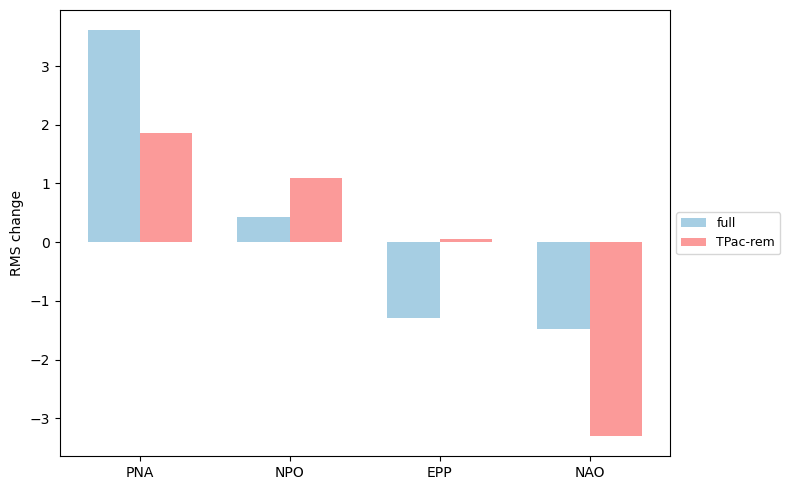

In [21]:
import numpy as np
import matplotlib.pyplot as plt


# Labels and colors
group_labels = ['PNA','NPO','EPP','NAO']
bar_labels = ['full', 'TPac-rem']
bar_colors = ['#a6cee3', '#fb9a99']  # pale blue and pale pink
markers = ['o','s','^','D','v','<','>','x']  # 8 markers
models_title = ['CESM2','CESM1','ACCESS','CanESM5','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']

n_groups = rms.shape[0]
n_bars = rms.shape[1]
x = np.arange(n_groups)
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(8,5))

# Plot bars
for i in range(n_bars):
    ax.bar(x + i*width - width/2, rms[:,i], width, color=bar_colors[i], label=bar_labels[i])

# Overlay symbols from rms2
#for g in range(n_groups):
#    for b in range(n_bars):
#        for m in range(rms2.shape[0]):  # 8 models
#            ax.plot(x[g] + b*width - width/2, rms2[m,g,b],
#                    marker=markers[m], color='k', linestyle='None', alpha=0.8,
#                    label=models_title[m] if g==0 and b==0 else "")  # only add label once for legend

# Labels and legend
ax.set_xticks(x)
ax.set_xticklabels(group_labels)
ax.set_ylabel('RMS change')

# Create a legend with bars and models
handles, labels = ax.get_legend_handles_labels()
# Remove duplicates from models
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))

# Move legend to the right outside the plot
ax.legend(by_label.values(), by_label.keys(),
          loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)

plt.tight_layout()


outputdir2='/glade/work/nmaher/SEOF_output/figs_final/revision/'
PP.savefig(outputdir2+'Figure11.png', dpi=300, bbox_inches='tight')
PP.show()